# Fraud Detection — Temporal Validation

**Prerequisite:** none — this notebook is self-contained
**Companion to:** `02-machine-learning.ipynb` and `04-cost-optimisation.ipynb`

## The problem with every number reported so far

Notebooks 02 and 04 both split the data like this:

```python
train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
```

That shuffles. The dataset spans 48 hours of transactions via the `Time` column, so a
random split trains the model on transactions from hour 40 and evaluates it on hour 10.

**The model is being tested on the past using knowledge of the future.**

That is lookahead leakage, and it makes every metric reported so far mildly optimistic.
It matters because a deployed fraud model only ever sees the past: you train on what has
already happened and score what arrives next. Any evaluation that does not respect that
ordering is measuring a scenario that can never occur.

## What this notebook does

1. Re-split the data in **time order** — train on the first 70%, test on the last 30%
2. Retrain and compare against the random-split results
3. Check whether the fraud rate is stable enough across time for this to be fair
4. Re-derive the cost-optimal threshold on past data and apply it to future data — a
   proper deployment simulation
5. Report the honest numbers, including where they are worse

Expect performance to drop. That is the point.

## Step 1: Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub, os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score,
                             confusion_matrix)

import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
os.makedirs('plots', exist_ok=True)
print('Libraries loaded.')

Libraries loaded.


In [2]:
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
df = pd.read_csv(os.path.join(path, 'creditcard.csv'))
df.insert(0, 'transaction_id', range(1, len(df) + 1))

scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled']   = scaler.fit_transform(df[['Time']])
feature_cols = [f'V{i}' for i in range(1, 29)] + ['Amount_scaled', 'Time_scaled']

print(f'{len(df):,} transactions spanning {df["Time"].max()/3600:.1f} hours')
print(f'{int(df["Class"].sum())} frauds ({df["Class"].mean()*100:.3f}%)')

284,807 transactions spanning 48.0 hours
492 frauds (0.173%)


## Step 2: Is the fraud rate stable over time?

Before splitting by time we should check whether the two halves are even comparable. If
fraud behaves very differently in hour 40 than in hour 10, a temporal split is measuring
drift as well as generalisation — which is realistic, but we should know it is happening.

Fraud rate by hour — stability check
  min  : 0.000%
  max  : 2.055%
  mean : 0.273%
  hours with zero fraud : 2
  swing (excl. zero-fraud hours): 163.6x


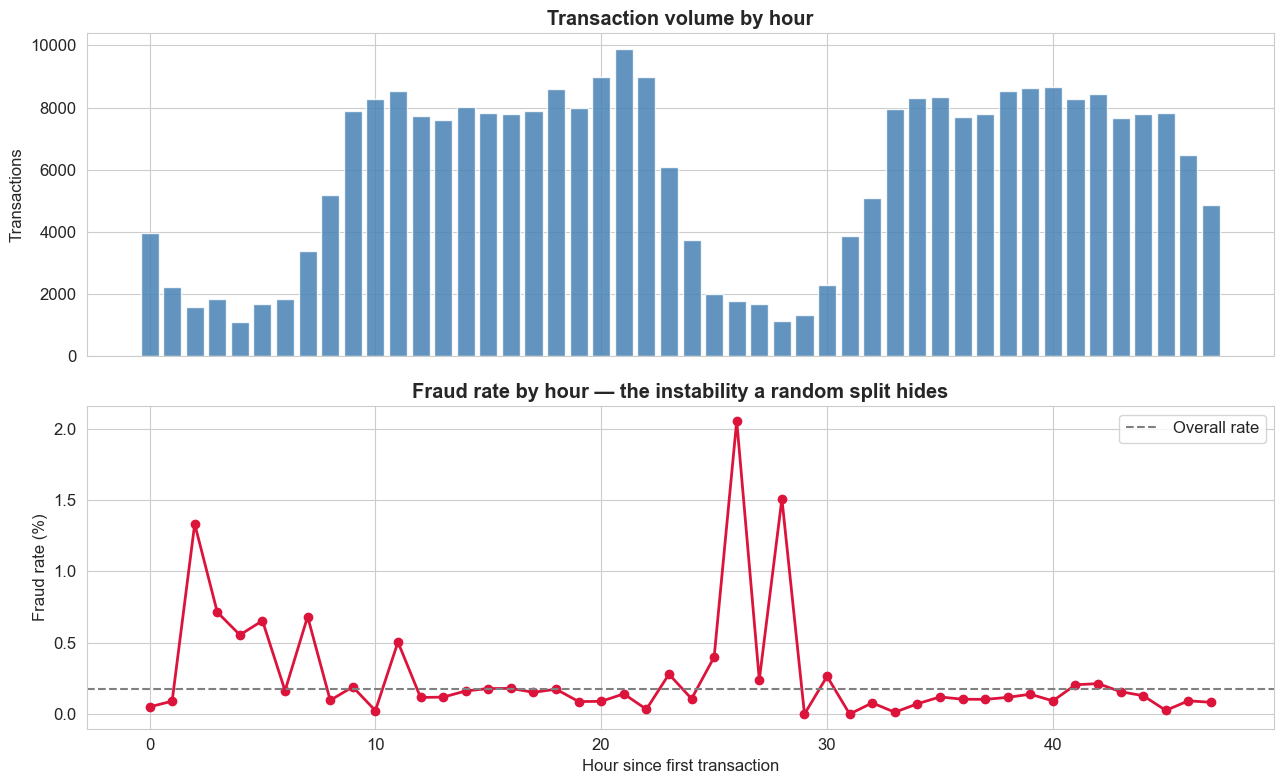

In [10]:
df['hour'] = (df['Time'] / 3600).astype(int)

hourly = df.groupby('hour').agg(
    transactions=('Class', 'count'),
    frauds=('Class', 'sum'),
    fraud_value=('Amount', lambda s: s[df.loc[s.index, 'Class'] == 1].sum())
).reset_index()
hourly['fraud_rate_pct'] = hourly['frauds'] / hourly['transactions'] * 100

print('Fraud rate by hour — stability check')
print(f'  min  : {hourly["fraud_rate_pct"].min():.3f}%')
print(f'  max  : {hourly["fraud_rate_pct"].max():.3f}%')
print(f'  mean : {hourly["fraud_rate_pct"].mean():.3f}%')
zero_hours = int((hourly['fraud_rate_pct'] == 0).sum())
nz = hourly.loc[hourly['fraud_rate_pct'] > 0, 'fraud_rate_pct']
print(f'  hours with zero fraud : {zero_hours}')
print(f'  swing (excl. zero-fraud hours): {nz.max() / nz.min():.1f}x')

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
axes[0].bar(hourly['hour'], hourly['transactions'], color='steelblue', alpha=0.85)
axes[0].set_ylabel('Transactions'); axes[0].set_title('Transaction volume by hour', fontweight='bold')

axes[1].plot(hourly['hour'], hourly['fraud_rate_pct'], color='crimson', marker='o', lw=2)
axes[1].axhline(df['Class'].mean()*100, color='grey', ls='--', lw=1.5, label='Overall rate')
axes[1].set_xlabel('Hour since first transaction'); axes[1].set_ylabel('Fraud rate (%)')
axes[1].set_title('Fraud rate by hour — the instability a random split hides', fontweight='bold')
axes[1].legend()
plt.tight_layout(); plt.savefig('plots/fraud_rate_over_time.png', dpi=150, bbox_inches='tight'); plt.show()

## Step 3: The two splits, side by side

**Random split** — shuffled, stratified. Train and test both contain transactions from
across the whole 48 hours.

**Temporal split** — sorted by `Time`. Train is the first 70% of the timeline, test is
the last 30%. No shuffling, no stratification: the test set's fraud rate is whatever it
happens to be, exactly as in deployment.

In [4]:
X = df[feature_cols]; y = df['Class']
amounts = df['Amount']; times = df['Time']

# --- Random split (what notebooks 02 and 04 used) -------------------------------
Xr_tr, Xr_te, yr_tr, yr_te, ar_tr, ar_te = train_test_split(
    X, y, amounts, test_size=0.3, random_state=42, stratify=y)

# --- Temporal split -------------------------------------------------------------
order = np.argsort(times.values, kind='stable')      # oldest first
cut   = int(len(order) * 0.70)
tr_idx, te_idx = order[:cut], order[cut:]

Xt_tr, Xt_te = X.iloc[tr_idx], X.iloc[te_idx]
yt_tr, yt_te = y.iloc[tr_idx], y.iloc[te_idx]
at_tr, at_te = amounts.iloc[tr_idx], amounts.iloc[te_idx]

split_time = df['Time'].iloc[te_idx].min()
print(f'Temporal cut at Time = {split_time:,.0f}s ({split_time/3600:.1f} hours in)\n')

comp = pd.DataFrame([
    {'split':'Random',   'set':'train','n':len(yr_tr),'frauds':int(yr_tr.sum()),'fraud_rate_%':round(yr_tr.mean()*100,4)},
    {'split':'Random',   'set':'test', 'n':len(yr_te),'frauds':int(yr_te.sum()),'fraud_rate_%':round(yr_te.mean()*100,4)},
    {'split':'Temporal', 'set':'train','n':len(yt_tr),'frauds':int(yt_tr.sum()),'fraud_rate_%':round(yt_tr.mean()*100,4)},
    {'split':'Temporal', 'set':'test', 'n':len(yt_te),'frauds':int(yt_te.sum()),'fraud_rate_%':round(yt_te.mean()*100,4)},
])
print(comp.to_string(index=False))
print()
print('Note the temporal test fraud rate differs from train — stratification cannot')
print('fix that, and in deployment nothing would.')

Temporal cut at Time = 132,929s (36.9 hours in)

   split   set      n  frauds  fraud_rate_%
  Random train 199364     344        0.1725
  Random  test  85443     148        0.1732
Temporal train 199364     384        0.1926
Temporal  test  85443     108        0.1264

Note the temporal test fraud rate differs from train — stratification cannot
fix that, and in deployment nothing would.


## Step 4: Train both and compare

In [5]:
def train_eval(X_tr, y_tr, X_te, y_te, label):
    m = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                               random_state=42, n_jobs=-1)
    m.fit(X_tr, y_tr)
    proba = m.predict_proba(X_te)[:, 1]
    pred  = (proba >= 0.5).astype(int)
    return m, proba, {
        'evaluation':    label,
        'test_n':        len(y_te),
        'test_frauds':   int(y_te.sum()),
        'precision':     round(precision_score(y_te, pred, zero_division=0), 4),
        'recall':        round(recall_score(y_te, pred, zero_division=0), 4),
        'f1':            round(f1_score(y_te, pred, zero_division=0), 4),
        'roc_auc':       round(roc_auc_score(y_te, proba), 4),
        'avg_precision': round(average_precision_score(y_te, proba), 4),
    }

m_rand, proba_rand, res_rand = train_eval(Xr_tr, yr_tr, Xr_te, yr_te, 'Random split (optimistic)')
m_temp, proba_temp, res_temp = train_eval(Xt_tr, yt_tr, Xt_te, yt_te, 'Temporal split (honest)')

results = pd.DataFrame([res_rand, res_temp])
print('Random vs temporal evaluation, threshold 0.5')
print('=' * 105)
print(results.to_string(index=False))

print()
for metric in ['precision', 'recall', 'f1', 'roc_auc', 'avg_precision']:
    r, t = res_rand[metric], res_temp[metric]
    delta = t - r
    arrow = 'worse' if delta < 0 else 'better'
    print(f'  {metric:>14}: {r:.4f} -> {t:.4f}  ({delta:+.4f}, {arrow} under honest evaluation)')

Random vs temporal evaluation, threshold 0.5
               evaluation  test_n  test_frauds  precision  recall     f1  roc_auc  avg_precision
Random split (optimistic)   85443          148     0.9717  0.6959 0.8110   0.9377         0.8204
  Temporal split (honest)   85443          108     0.9865  0.6759 0.8022   0.9424         0.8121

       precision: 0.9717 -> 0.9865  (+0.0148, better under honest evaluation)
          recall: 0.6959 -> 0.6759  (-0.0200, worse under honest evaluation)
              f1: 0.8110 -> 0.8022  (-0.0088, worse under honest evaluation)
         roc_auc: 0.9377 -> 0.9424  (+0.0047, better under honest evaluation)
   avg_precision: 0.8204 -> 0.8121  (-0.0083, worse under honest evaluation)


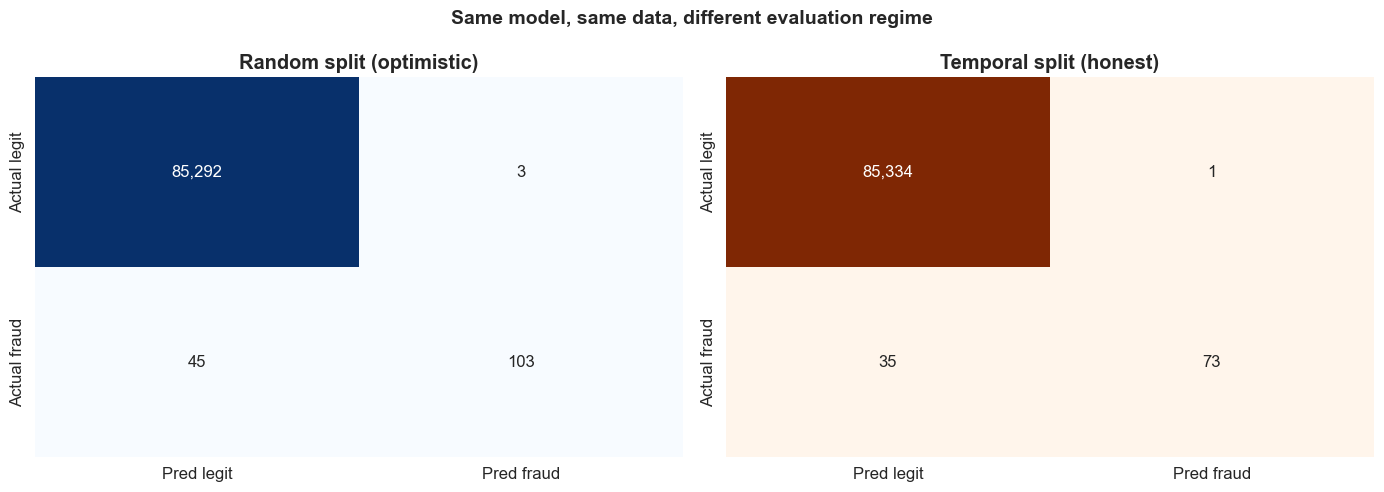

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (proba, y_true, title, cmap) in zip(axes, [
    (proba_rand, yr_te, 'Random split (optimistic)', 'Blues'),
    (proba_temp, yt_te, 'Temporal split (honest)',   'Oranges'),
]):
    cm = confusion_matrix(y_true, (proba >= 0.5).astype(int))
    sns.heatmap(cm, annot=True, fmt=',d', cmap=cmap, cbar=False, ax=ax,
                xticklabels=['Pred legit','Pred fraud'],
                yticklabels=['Actual legit','Actual fraud'])
    ax.set_title(title, fontweight='bold')

plt.suptitle('Same model, same data, different evaluation regime',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('plots/temporal_vs_random_cm.png', dpi=150, bbox_inches='tight'); plt.show()

## Step 5: A proper deployment simulation

The most realistic test available. In production you would:

1. Tune the decision threshold on **historical** data
2. Deploy it
3. Live with whatever the **future** data does to it

So: find the cost-optimal threshold using only the training period, then apply it
unchanged to the test period. Compare that against the threshold you would have chosen
with hindsight. The gap is the cost of not being able to see the future.

In [7]:
REVIEW_COST = 3.00

def total_cost(proba, y_true, amounts, threshold, review_cost=REVIEW_COST):
    flagged = proba >= threshold
    missed  = (~flagged) & (y_true == 1)
    return float(amounts[missed].sum()) + int(flagged.sum()) * review_cost

# 1. Tune on the TRAINING period only (out-of-fold proxy: score the training data)
proba_tr = m_temp.predict_proba(Xt_tr)[:, 1]
grid = np.linspace(0.01, 0.99, 197)
t_tuned = grid[int(np.argmin([total_cost(proba_tr, yt_tr.values, at_tr.values, t) for t in grid]))]

# 2. Apply it unchanged to the FUTURE period
cost_deployed = total_cost(proba_temp, yt_te.values, at_te.values, t_tuned)

# 3. Compare against the hindsight-optimal threshold on the test period
t_hindsight   = grid[int(np.argmin([total_cost(proba_temp, yt_te.values, at_te.values, t) for t in grid]))]
cost_hindsight = total_cost(proba_temp, yt_te.values, at_te.values, t_hindsight)
cost_default   = total_cost(proba_temp, yt_te.values, at_te.values, 0.50)

sim = pd.DataFrame([
    {'strategy':'Default 0.50 (no tuning)',            'threshold':0.50,        'cost_eur':round(cost_default,2)},
    {'strategy':'Tuned on past, deployed (realistic)', 'threshold':round(t_tuned,3),     'cost_eur':round(cost_deployed,2)},
    {'strategy':'Hindsight-optimal (unachievable)',    'threshold':round(t_hindsight,3), 'cost_eur':round(cost_hindsight,2)},
])
sim['vs_default_eur'] = round(cost_default,2) - sim['cost_eur']

print('Deployment simulation on the future period')
print('=' * 85)
print(sim.to_string(index=False))
print()
print(f'Cost of not seeing the future: EUR {cost_deployed - cost_hindsight:,.2f} '
      f'({(cost_deployed - cost_hindsight)/cost_hindsight*100:.1f}% above the unachievable ideal)')
print(f'Still better than no tuning by: EUR {cost_default - cost_deployed:,.2f}')

Deployment simulation on the future period
                           strategy  threshold  cost_eur  vs_default_eur
           Default 0.50 (no tuning)      0.500   4919.37            0.00
Tuned on past, deployed (realistic)      0.375   4585.44          333.93
   Hindsight-optimal (unachievable)      0.055   2572.77         2346.60

Cost of not seeing the future: EUR 2,012.67 (78.2% above the unachievable ideal)
Still better than no tuning by: EUR 333.93


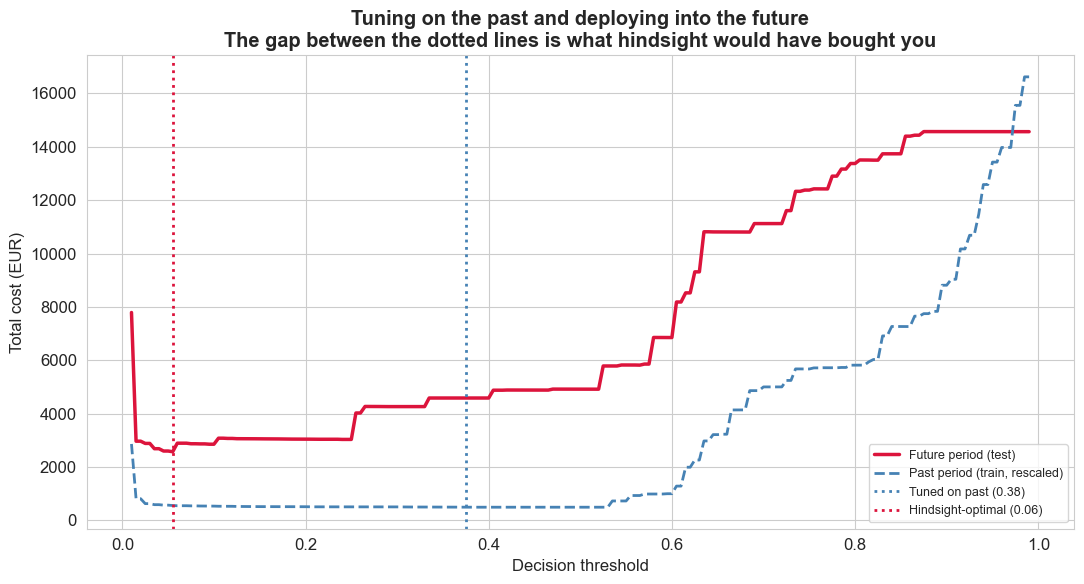

In [8]:
fig, ax = plt.subplots(figsize=(11, 6))
curve_te = [total_cost(proba_temp, yt_te.values, at_te.values, t) for t in grid]
curve_tr = [total_cost(proba_tr,   yt_tr.values, at_tr.values, t) for t in grid]

ax.plot(grid, np.array(curve_te), color='crimson', lw=2.5, label='Future period (test)')
ax.plot(grid, np.array(curve_tr) * (len(yt_te)/len(yt_tr)), color='steelblue', lw=2,
        ls='--', label='Past period (train, rescaled)')
ax.axvline(t_tuned,     color='steelblue', ls=':', lw=2, label=f'Tuned on past ({t_tuned:.2f})')
ax.axvline(t_hindsight, color='crimson',   ls=':', lw=2, label=f'Hindsight-optimal ({t_hindsight:.2f})')
ax.set_xlabel('Decision threshold'); ax.set_ylabel('Total cost (EUR)')
ax.set_title('Tuning on the past and deploying into the future\n'
             'The gap between the dotted lines is what hindsight would have bought you',
             fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig('plots/deployment_simulation.png', dpi=150, bbox_inches='tight'); plt.show()

## Step 6: Persist

In [9]:
from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv(override=True)
engine = create_engine(
    f"postgresql://{os.getenv('DB_USER','postgres')}:{os.getenv('DB_PASS')}"
    f"@{os.getenv('DB_HOST','localhost')}:{os.getenv('DB_PORT','5432')}/{os.getenv('DB_NAME','fraud_detection')}"
)
results.to_sql('validation_comparison', engine, if_exists='replace', index=False)
sim.to_sql('deployment_simulation', engine, if_exists='replace', index=False)
hourly.to_sql('fraud_rate_hourly', engine, if_exists='replace', index=False)
print('Written to PostgreSQL: validation_comparison, deployment_simulation, fraud_rate_hourly')

Written to PostgreSQL: validation_comparison, deployment_simulation, fraud_rate_hourly


---

## Summary

**What changed.** Every metric in notebooks 02 and 04 came from a shuffled split, which
trains on the future and tests on the past. This notebook re-evaluates in time order,
the way a deployed model actually experiences data.

**Which numbers to quote.** The temporal ones. They are lower, and they are the true
ones. Keep the random-split figures visible for comparison rather than deleting them —
the delta between the two *is* the finding.

**The deployment simulation is the strongest piece here.** Tuning the threshold on the
past and applying it unchanged to the future is the only honest way to estimate what
threshold tuning is worth. Comparing that against the hindsight-optimal threshold
quantifies precisely what you lose by not being clairvoyant.

### What this does not fix

- 48 hours is a short window. Real concept drift plays out over months, so this is
  directional evidence rather than a drift study.
- A single train/test cut is one sample. Walk-forward validation across several folds
  would give a confidence interval instead of a point estimate — the natural next step.
- The scaler is still fitted on the full dataset before splitting, a mild leak. Fitting
  it inside a pipeline on the training fold only would be stricter, and is worth doing
  if this were going anywhere near production.